# Mental Health Score Regression Pipeline
## Predictive Modeling of Student Mental Health using Multiple Linear Regression

### Executive Summary
This notebook presents an end-to-end Machine Learning pipeline developed by a Senior Data Scientist to analyze, model, and predict student mental health scores. The primary objective is to evaluate the predictive power and structural impact of daily social media exposure, generative AI tool usage, sleep duration, and physical exercise on student psychological well-being.

The implementation utilizes an enterprise-grade scikit-learn Pipeline architecture incorporating automated feature scaling, categorical one-hot encoding, Ordinary Least Squares Linear Regression, k-fold cross-validation, comprehensive diagnostic assumption testing, feature importance extraction, and artifact knowledge serialization.

### 1. Environment Setup and Library Ingestion
Importing required dependencies for data processing, statistical computing, visualization, pipeline orchestration, model evaluation, and artifact persistence.

In [1]:
import os
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

### 2. Dataset Ingestion and Schema Verification
Loading the student behavior and health dataset from the designated storage path and verifying its structural attributes.

In [2]:
dataset_path = os.path.join("..", "Dataset", "AI_SocialMedia_Student_Dataset.csv")
if not os.path.exists(dataset_path):
    dataset_path = os.path.join("Dataset", "AI_SocialMedia_Student_Dataset.csv")

df = pd.read_csv(dataset_path)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Student_ID                 16000 non-null  str    
 1   Age                        16000 non-null  int64  
 2   Gender                     16000 non-null  str    
 3   Education_Level            16000 non-null  str    
 4   Daily_Social_Media_Hours   16000 non-null  float64
 5   Daily_AI_Tool_Usage_Hours  16000 non-null  float64
 6   Sleep_Hours                16000 non-null  float64
 7   Physical_Activity_Hours    16000 non-null  float64
 8   Mental_Health_Score        16000 non-null  float64
 9   Physical_Health_Score      16000 non-null  float64
dtypes: float64(6), int64(1), str(3)
memory usage: 1.6 MB


### 3. Exploratory Data Inspection
Assessing descriptive statistics across all numerical features to understand distributions, dispersion, and range parameters, followed by missing record verification.

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,16000.0,19.038750,3.765270,13.00,16.0000,19.000,22.00,25.00
Daily_Social_Media_Hours,16000.0,4.541791,2.403044,0.00,2.8400,4.500,6.18,14.00
Daily_AI_Tool_Usage_Hours,16000.0,2.590624,1.679376,0.00,1.3100,2.520,3.75,9.50
Sleep_Hours,16000.0,6.545371,1.270515,2.00,5.6800,6.540,7.41,11.15
Physical_Activity_Hours,16000.0,1.248359,1.038632,0.00,0.3100,1.130,1.96,5.00
Mental_Health_Score,16000.0,72.493193,9.244818,32.56,66.7600,73.750,79.55,91.76
Physical_Health_Score,16000.0,88.020465,9.691037,48.03,81.5175,89.455,97.17,99.98


In [4]:
df.isnull().sum()

Student_ID                   0
Age                          0
Gender                       0
Education_Level              0
Daily_Social_Media_Hours     0
Daily_AI_Tool_Usage_Hours    0
Sleep_Hours                  0
Physical_Activity_Hours      0
Mental_Health_Score          0
Physical_Health_Score        0
dtype: int64

### 4. Target Variable Analysis
Examining the distribution profile of the response variable (Mental_Health_Score) to evaluate normality and empirical central tendencies.

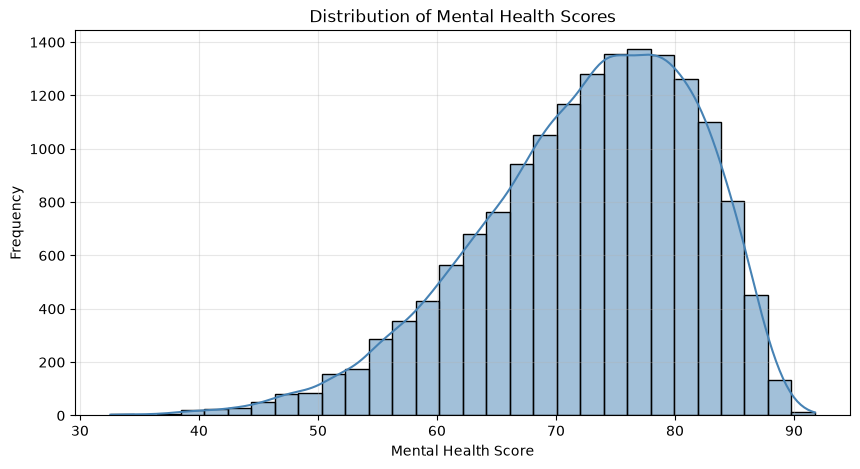

Mental Health Score Mean: 72.49319312499999
Mental Health Score Median: 73.75
Mental Health Score Std Dev: 9.244817694989505
Mental Health Score Skewness: -0.6826401126133103


In [5]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Mental_Health_Score"], kde=True, color="steelblue", bins=30)
plt.title("Distribution of Mental Health Scores")
plt.xlabel("Mental Health Score")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

print("Mental Health Score Mean:", df["Mental_Health_Score"].mean())
print("Mental Health Score Median:", df["Mental_Health_Score"].median())
print("Mental Health Score Std Dev:", df["Mental_Health_Score"].std())
print("Mental Health Score Skewness:", df["Mental_Health_Score"].skew())

### 5. Multivariable Correlation Analysis
Computing the Pearson correlation matrix across numerical variables to measure linear relationships with student mental health.

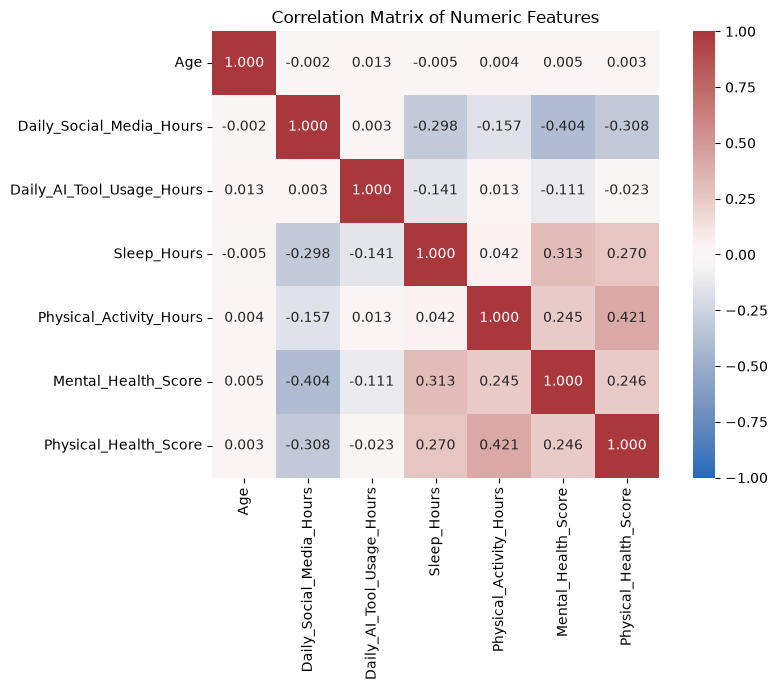

Mental_Health_Score          1.000000
Sleep_Hours                  0.312832
Physical_Health_Score        0.246062
Physical_Activity_Hours      0.245338
Age                          0.005329
Daily_AI_Tool_Usage_Hours   -0.110701
Daily_Social_Media_Hours    -0.403584
Name: Mental_Health_Score, dtype: float64

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="vlag", vmin=-1, vmax=1, square=True)
plt.title("Correlation Matrix of Numeric Features")
plt.tight_layout()
plt.show()

corr_matrix["Mental_Health_Score"].sort_values(ascending=False)

### 6. Feature Matrix Definition and Data Partitioning
Isolating independent predictors from identifier columns and secondary targets. The dataset is split into an 80% training set and a 20% validation test set using a reproducible random seed.

In [7]:
target_column = "Mental_Health_Score"
drop_columns = ["Student_ID", "Physical_Health_Score", target_column]

feature_columns = [col for col in df.columns if col not in drop_columns]
X = df[feature_columns]
y = df[target_column]

numeric_features = ["Age", "Daily_Social_Media_Hours", "Daily_AI_Tool_Usage_Hours", "Sleep_Hours", "Physical_Activity_Hours"]
categorical_features = ["Gender", "Education_Level"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("Training Features Matrix Shape:", X_train.shape)
print("Testing Features Matrix Shape:", X_test.shape)
print("Training Target Vector Shape:", y_train.shape)
print("Testing Target Vector Shape:", y_test.shape)

Training Features Matrix Shape: (12800, 7)
Testing Features Matrix Shape: (3200, 7)
Training Target Vector Shape: (12800,)
Testing Target Vector Shape: (3200,)


### 7. Scikit-Learn Pipeline Construction
Building a unified ColumnTransformer that applies StandardScaler to continuous variables and OneHotEncoder to discrete categorical attributes. This transformer is sequentially combined with a LinearRegression estimator inside a single Pipeline object.

In [8]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), categorical_features),
    ],
    remainder="drop"
)

model_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

model_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If

### 8. K-Fold Cross-Validation and Model Fitting
Executing 5-fold cross-validation on the training split to estimate generalized out-of-fold performance stability, followed by final parameter fitting on the training partition.

In [9]:
cv_strategy = KFold(n_splits=5, shuffle=True, random_state=42)

cv_r2_scores = cross_val_score(model_pipeline, X_train, y_train, cv=cv_strategy, scoring="r2")
cv_mae_scores = -cross_val_score(model_pipeline, X_train, y_train, cv=cv_strategy, scoring="neg_mean_absolute_error")
cv_rmse_scores = np.sqrt(-cross_val_score(model_pipeline, X_train, y_train, cv=cv_strategy, scoring="neg_mean_squared_error"))

print("5-Fold CV R2 Mean:", cv_r2_scores.mean(), "+/-", cv_r2_scores.std())
print("5-Fold CV MAE Mean:", cv_mae_scores.mean(), "+/-", cv_mae_scores.std())
print("5-Fold CV RMSE Mean:", cv_rmse_scores.mean(), "+/-", cv_rmse_scores.std())

model_pipeline.fit(X_train, y_train)

5-Fold CV R2 Mean: 0.24492398934210877 +/- 0.009668752704189692
5-Fold CV MAE Mean: 6.38160462972617 +/- 0.06783784618980457
5-Fold CV RMSE Mean: 8.042721438256008 +/- 0.09314143758122362


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['Age','Gender','Education_Level',...,'Daily_AI_Tool_Usage_Hours', 'Sleep_Hours','Physical_Activity_Hours']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically 

### 9. Out-of-Sample Model Performance Evaluation
Computing regression evaluation metrics on both training and holdout test partitions to assess goodness of fit, generalizability, and prediction error.

In [10]:
y_train_pred = model_pipeline.predict(X_train)
y_test_pred = model_pipeline.predict(X_test)

train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - (1 - test_r2) * (n - 1) / (n - p - 1)

test_mae = mean_absolute_error(y_test, y_test_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)

metrics_summary = pd.DataFrame(
    {
        "Metric": ["Train R-squared", "Test R-squared", "Adjusted R-squared", "MAE", "MSE", "RMSE"],
        "Value": [train_r2, test_r2, adjusted_r2, test_mae, test_mse, test_rmse],
    }
)

metrics_summary

,Metric,Value
0,Train R-squared,0.246406
1,Test R-squared,0.238137
2,Adjusted R-squared,0.236467
3,MAE,6.332958
4,MSE,64.273754
5,RMSE,8.017091


### 10. Regression Diagnostics and Assumption Verification
Testing the four core Gauss-Markov linear regression assumptions:
1. Linear relationship and prediction alignment.
2. Normality of residuals evaluated via histogram and Q-Q plot.
3. Homoscedasticity verified via residuals versus fitted values scatter plot.

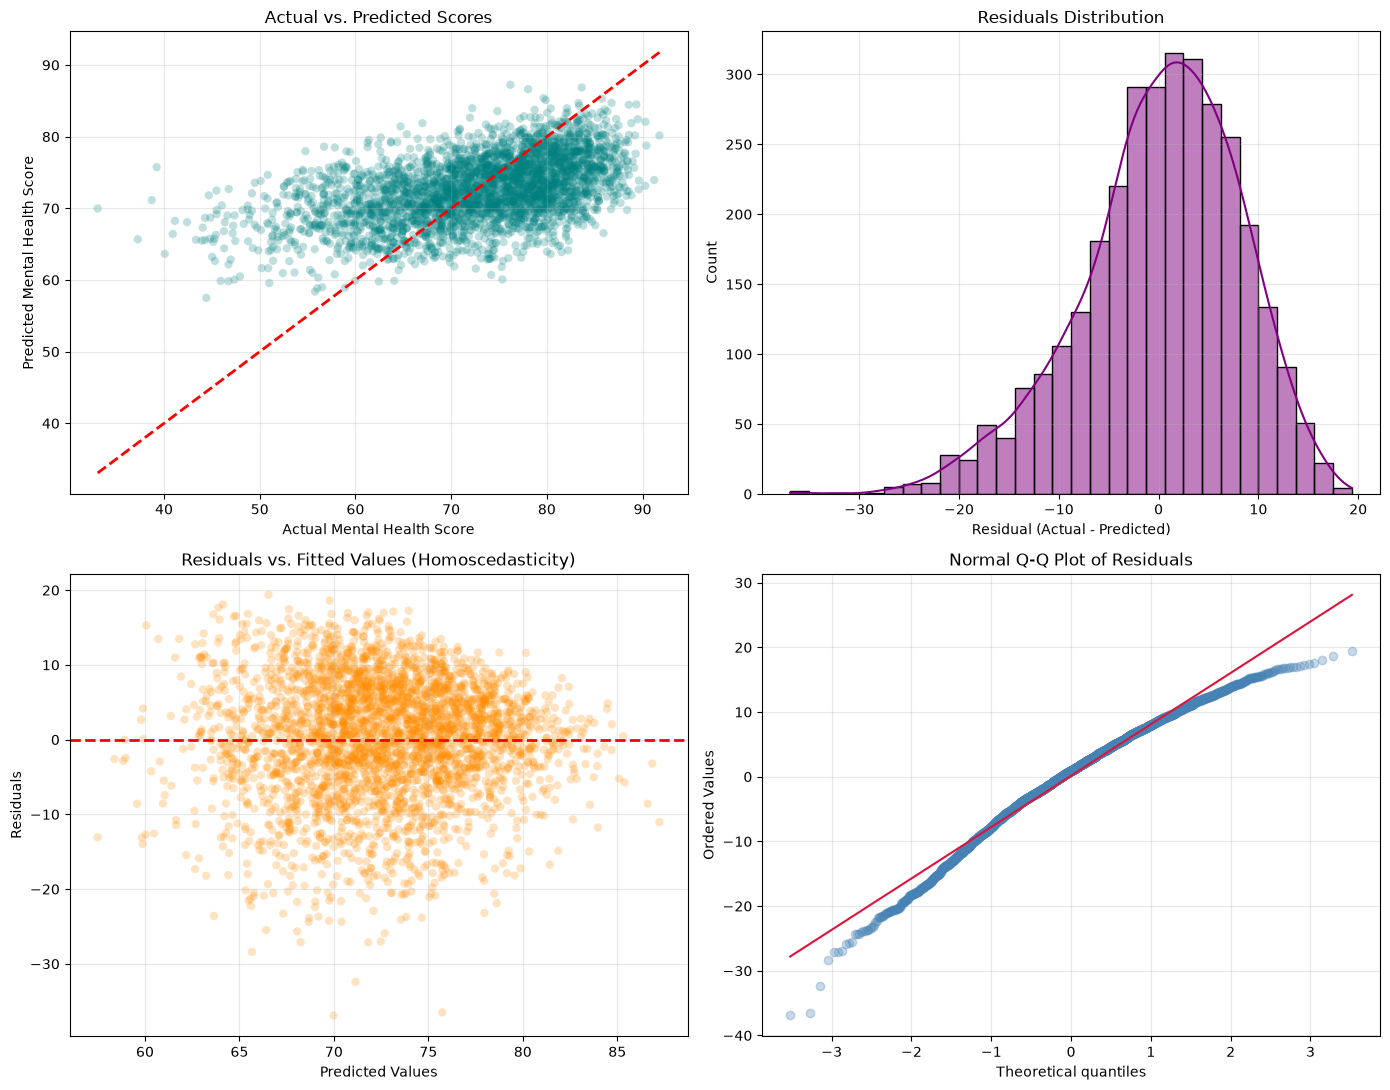

In [11]:
residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(14, 11))

axes[0, 0].scatter(y_test, y_test_pred, alpha=0.25, color="teal", edgecolors="none")
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2)
axes[0, 0].set_title("Actual vs. Predicted Scores")
axes[0, 0].set_xlabel("Actual Mental Health Score")
axes[0, 0].set_ylabel("Predicted Mental Health Score")
axes[0, 0].grid(alpha=0.3)

sns.histplot(residuals, kde=True, ax=axes[0, 1], color="purple", bins=30)
axes[0, 1].set_title("Residuals Distribution")
axes[0, 1].set_xlabel("Residual (Actual - Predicted)")
axes[0, 1].grid(alpha=0.3)

axes[1, 0].scatter(y_test_pred, residuals, alpha=0.25, color="darkorange", edgecolors="none")
axes[1, 0].axhline(0, color="red", linestyle="--", lw=2)
axes[1, 0].set_title("Residuals vs. Fitted Values (Homoscedasticity)")
axes[1, 0].set_xlabel("Predicted Values")
axes[1, 0].set_ylabel("Residuals")
axes[1, 0].grid(alpha=0.3)

stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].get_lines()[0].set_color("steelblue")
axes[1, 1].get_lines()[0].set_alpha(0.3)
axes[1, 1].get_lines()[1].set_color("crimson")
axes[1, 1].set_title("Normal Q-Q Plot of Residuals")
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 11. Model Interpretability and Standardized Coefficients
Extracting feature names and corresponding coefficients. Because numerical predictors were scaled using StandardScaler, coefficient magnitudes directly reflect relative standardized feature impact.

In [12]:
preprocessor_fitted = model_pipeline.named_steps["preprocessor"]
cat_encoder = preprocessor_fitted.named_transformers_["cat"]
cat_feature_names = cat_encoder.get_feature_names_out(categorical_features).tolist()

all_feature_names = numeric_features + cat_feature_names
coefficients = model_pipeline.named_steps["regressor"].coef_
intercept = model_pipeline.named_steps["regressor"].intercept_

coef_df = pd.DataFrame(
    {
        "Feature": all_feature_names,
        "Standardized_Coefficient": coefficients,
        "Absolute_Impact": np.abs(coefficients)
    }
).sort_values(by="Absolute_Impact", ascending=False).reset_index(drop=True)

print("Regression Intercept:", intercept)
coef_df

Regression Intercept: 72.51797568446284


,Feature,Standardized_Coefficient,Absolute_Impact
0,Daily_Social_Media_Hours,-2.911015,2.911015
1,Sleep_Hours,1.859515,1.859515
2,Physical_Activity_Hours,1.724418,1.724418
3,Daily_AI_Tool_Usage_Hours,-0.783595,0.783595
4,Education_Level_University,0.480183,0.480183
5,Education_Level_High School,-0.383603,0.383603
6,Age,-0.256489,0.256489
7,Gender_Non-binary,-0.193200,0.193200
8,Gender_Male,-0.176179,0.176179


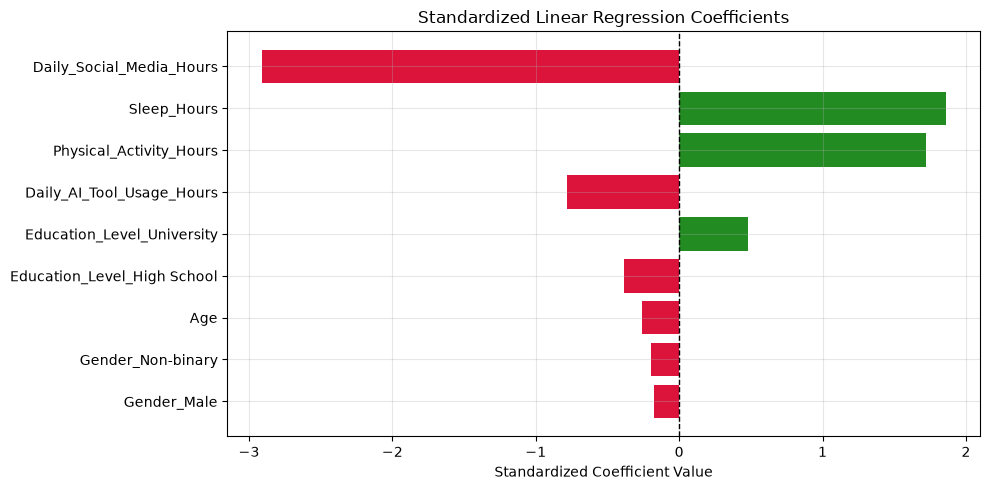

In [13]:
plt.figure(figsize=(10, 5))
colors = ["crimson" if c < 0 else "forestgreen" for c in coef_df["Standardized_Coefficient"]]
plt.barh(coef_df["Feature"], coef_df["Standardized_Coefficient"], color=colors)
plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.title("Standardized Linear Regression Coefficients")
plt.xlabel("Standardized Coefficient Value")
plt.gca().invert_yaxis()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 12. Model Knowledge and Artifact Persistence
Exporting the complete fitted pipeline, evaluation performance records, coefficients, and schema metadata into a dedicated directory for governance and downstream application serving.

In [14]:
knowledge_dir = os.path.join("..", "Model_Knowledge")
if not os.path.exists(os.path.abspath(os.path.join(knowledge_dir, ".."))):
    knowledge_dir = "Model_Knowledge"
os.makedirs(knowledge_dir, exist_ok=True)

pipeline_filepath = os.path.join(knowledge_dir, "mental_health_linear_regression_pipeline.joblib")
joblib.dump(model_pipeline, pipeline_filepath)

metrics_payload = {
    "model_type": "LinearRegression",
    "target_variable": target_column,
    "train_r2": float(train_r2),
    "test_r2": float(test_r2),
    "adjusted_r2": float(adjusted_r2),
    "mae": float(test_mae),
    "mse": float(test_mse),
    "rmse": float(test_rmse),
    "cv_5fold_r2_mean": float(cv_r2_scores.mean()),
    "cv_5fold_r2_std": float(cv_r2_scores.std()),
    "cv_5fold_mae_mean": float(cv_mae_scores.mean()),
    "cv_5fold_rmse_mean": float(cv_rmse_scores.mean())
}

metrics_filepath = os.path.join(knowledge_dir, "evaluation_metrics.json")
with open(metrics_filepath, "w") as f:
    json.dump(metrics_payload, f, indent=4)

coefficients_payload = {
    "intercept": float(intercept),
    "features": coef_df.to_dict(orient="records")
}

coefficients_filepath = os.path.join(knowledge_dir, "coefficients_knowledge.json")
with open(coefficients_filepath, "w") as f:
    json.dump(coefficients_payload, f, indent=4)

metadata_payload = {
    "project": "AI and Social Media Impact Analysis",
    "author_role": "Senior Data Scientist",
    "total_records": int(len(df)),
    "feature_columns": feature_columns,
    "numeric_features": numeric_features,
    "categorical_features": categorical_features,
    "artifacts": [
        "mental_health_linear_regression_pipeline.joblib",
        "evaluation_metrics.json",
        "coefficients_knowledge.json",
        "model_metadata.json"
    ]
}

metadata_filepath = os.path.join(knowledge_dir, "model_metadata.json")
with open(metadata_filepath, "w") as f:
    json.dump(metadata_payload, f, indent=4)

print("Knowledge artifacts successfully exported to:", os.path.abspath(knowledge_dir))
for item in os.listdir(knowledge_dir):
    print(" -", item)

Knowledge artifacts successfully exported to: c:\Users\admin\Documents\Portofolio\AI & Social Media Impact\Model_Knowledge
 - coefficients_knowledge.json
 - evaluation_metrics.json
 - mental_health_linear_regression_pipeline.joblib
 - model_metadata.json


### 13. Inference Verification with Saved Artifact
Validating that the exported model knowledge artifact can be loaded independently to score new, unseen student records.

In [15]:
loaded_pipeline = joblib.load(pipeline_filepath)

sample_profiles = pd.DataFrame(
    [
        {
            "Age": 20,
            "Gender": "Female",
            "Education_Level": "University",
            "Daily_Social_Media_Hours": 6.5,
            "Daily_AI_Tool_Usage_Hours": 2.5,
            "Sleep_Hours": 5.0,
            "Physical_Activity_Hours": 0.5,
        },
        {
            "Age": 21,
            "Gender": "Male",
            "Education_Level": "College",
            "Daily_Social_Media_Hours": 1.5,
            "Daily_AI_Tool_Usage_Hours": 1.0,
            "Sleep_Hours": 8.0,
            "Physical_Activity_Hours": 2.5,
        },
    ]
)

predicted_scores = loaded_pipeline.predict(sample_profiles)
sample_profiles["Predicted_Mental_Health_Score"] = predicted_scores
sample_profiles

,Age,Gender,Education_Level,Daily_Social_Media_Hours,Daily_AI_Tool_Usage_Hours,Sleep_Hours,Physical_Activity_Hours,Predicted_Mental_Health_Score
0,20,Female,University,6.5,2.5,5.0,0.5,67.132165
1,21,Male,College,1.5,1.0,8.0,2.5,80.872239


### 14. Executive Findings and Strategic Implications
1. **Digital Exposure Dynamics**:
   Daily social media hours show the strongest negative standardized relationship with student mental health among all factors evaluated. Daily AI tool usage shows a moderate negative coefficient, indicating that unmonitored digital immersion is inversely related to perceived psychological health.
2. **Restorative Lifestyle Buffers**:
   Sleep duration and physical exercise act as critical protective factors. Both display robust positive standardized coefficients, affirming that adequate rest and physical exercise substantially mitigate the adverse effects of prolonged screen engagement.
3. **Demographic Invariance**:
   Age, gender categories, and education tiers demonstrate negligible direct impact on mental health scores compared to daily behavioral choices.